In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()

Saving task3.zip to task3.zip


In [8]:
import zipfile

zip_path = "task3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/intel_dataset")

In [9]:
import os

for root, dirs, files in os.walk("/content/intel_dataset"):
    print(root)
    print(dirs[:10])
    break

/content/intel_dataset
['seg_test', 'seg_train', 'seg_pred']


In [10]:
train_dir = "/content/intel_dataset/seg_train/seg_train"
test_dir = "/content/intel_dataset/seg_test/seg_test"

In [11]:
class_names = os.listdir(train_dir)

print(class_names)

['buildings', 'sea', 'street', 'glacier', 'mountain', 'forest']


In [12]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [13]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 14034 files belonging to 6 classes.


In [14]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [15]:
class_names = train_dataset.class_names

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


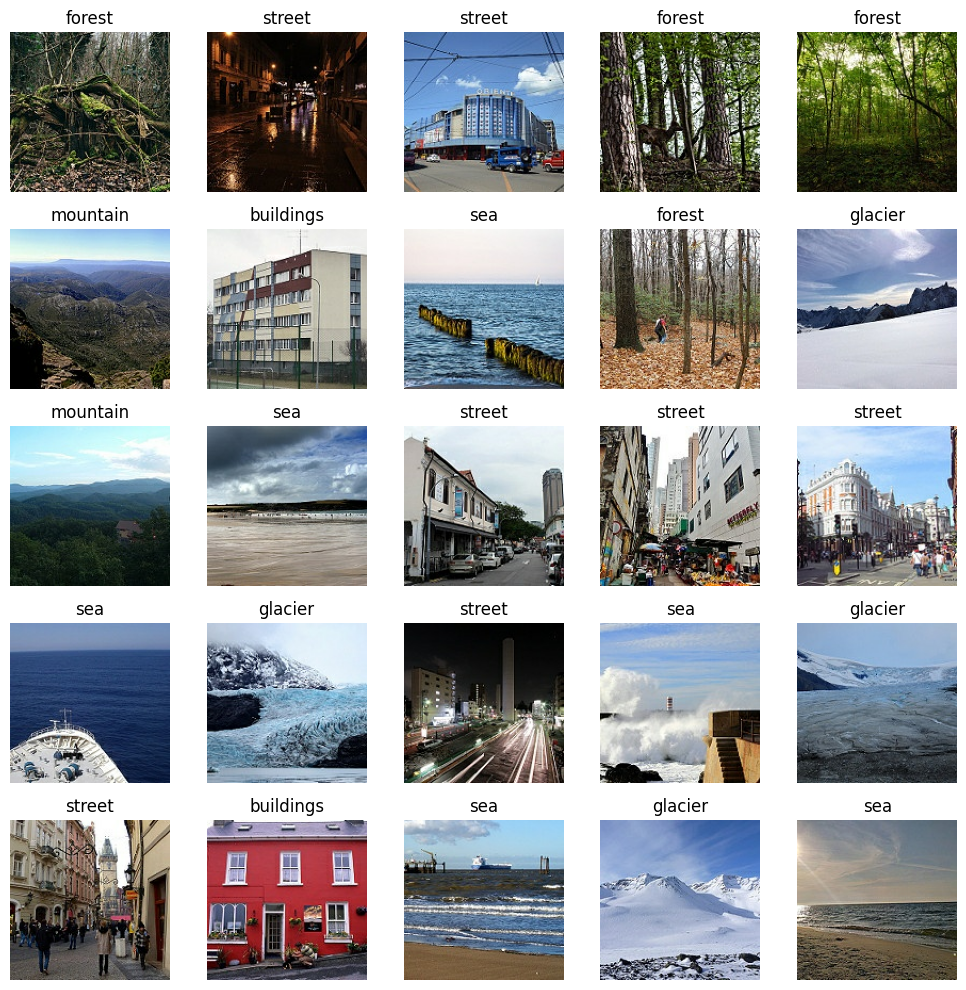

In [16]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [33]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,550 (3.98 MB)

 Trainable params: 1,044,550 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5098 - loss: 1.2287 - val_accuracy: 0.6313 - val_loss: 0.9809
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6254 - loss: 0.9683 - val_accuracy: 0.6910 - val_loss: 0.8256
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.6846 - loss: 0.8534 - val_accuracy: 0.7010 - val_loss: 0.8148
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7210 - loss: 0.7680 - val_accuracy: 0.7607 - val_loss: 0.6652
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7450 - loss: 0.7059 - val_accuracy: 0.7343 - val_loss: 0.7586
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7644 - loss: 0.6588 - val_accuracy: 0.7930 - val_loss: 0.5742
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7788 - loss: 0.6150 - val_accuracy: 0.7840 - val_loss: 0.5911
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7936 - loss: 0.5891 - 

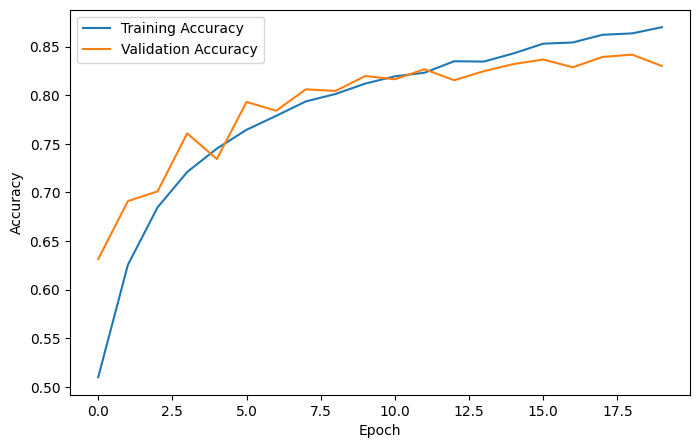

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

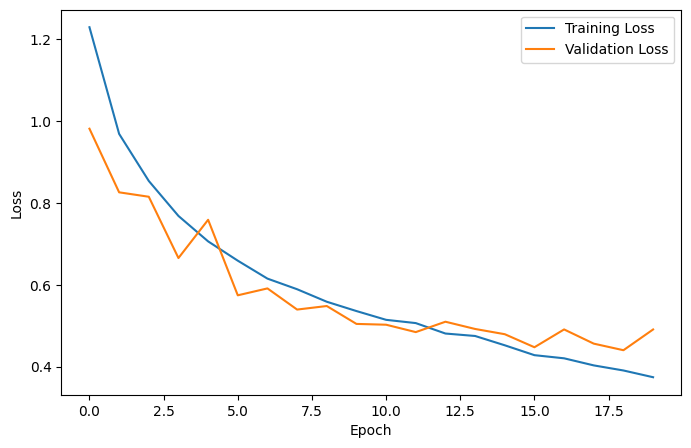

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8300 - loss: 0.4909
Test Accuracy: 0.8299999833106995
